# Meshing

Implements the paper's Section 2.4.5, following on from
[point_cloud_registration.ipynb](point_cloud_registration.ipynb):

> Following the point-cloud registration and merging operations described above, the points
> require connecting to form a surface mesh before texturing can be applied. Poisson surface
> reconstruction was used for this stage and was chosen for its relative simplicity and
> reliability. Some care is needed to avoid loss of detail on inscribed surfaces. We found that
> an octree depth of 14 gave a good compromise, retaining the detail of the inscriptions with a
> tractable computational complexity.

Implemented via `open3d` (see `utils/meshing.py`), whose Poisson filter wraps Kazhdan's own
reference PoissonRecon implementation. The mesh this
notebook writes is a plain vertex-coloured PLY, which MeshLab reads natively, so Step 9 can still
use MeshLab even though this step no longer does.

**Pipeline in this notebook:**
1. Load Step 7's merged, registered point-cloud and per-point confidence.
2. **Remove isolated points** - not in the paper, added here after finding that Poisson
   reconstructs a small, completely disconnected "bubble" surface off in empty space on this
   replica's own merged cloud. The cause turned out to be a handful of near-isolated points
   (registration/fusion debris, not a real second surface) - Poisson fits one *global* implicit
   function, so even a few far-flung points, each with their own plausible local normal, can pull
   its zero-level-set out into a sizeable phantom surface. Removing them from the point cloud
   avoids the bubble at the source, rather than needing to run the reconstruction once just to
   find and trim it afterwards.
3. Estimate consistently-oriented per-point normals (Riemannian-graph propagation, not a
   single-viewpoint heuristic - the merged cloud combines several original viewpoints) - Poisson
   needs these; it can't work from raw positions alone.
4. **Screened Poisson surface reconstruction** at the paper's own `depth=14`.
5. **Trim low-density vertices and disconnected debris** - not in the paper, added after finding
   that some objects present thin, sparsely-sampled structures (e.g. a narrow base) that Poisson
   doesn't reconstruct thin - it extrapolates past the last real point and balloons into a rounded
   "blob" with no points behind it. Unlike Step 2's isolated-point removal, this isn't caused by
   disconnected debris in the *input* cloud; it happens even on a clean cloud, because Poisson
   fits one smooth global implicit function and has to do *something* wherever sample density
   drops. Its own per-vertex density estimate (computed for free in Step 4, previously unused)
   flags exactly this: dropping the lowest-density tail removes the extrapolated blob while a
   real thin structure - lower density than the object's bulk, but still genuinely supported by
   points - mostly survives. Dropping vertices out of the mesh's middle leaves small disconnected
   shell fragments along the cut, which are cleared by keeping only sufficiently large connected
   triangle components.
6. Write the resulting mesh to `outputs/mesh/mesh.ply`, ready for Step 9 (Texturing).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from utils import meshing as mesh
from utils import registration as reg

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Parameters

In [2]:
ROOT = Path.cwd()
MERGED_PLY = ROOT / "outputs" / "merged" / "merged.ply"
MERGED_CONFIDENCE = ROOT / "outputs" / "merged" / "merged_confidence.npy"
OUT_DIR = ROOT / "outputs" / "mesh"
OUT_MESH_PLY = OUT_DIR / "mesh.ply"

# Isolated-point removal (not paper spec - see Step 2 below). Connects points within
# ISOLATION_RADIUS_MM of each other; drops any resulting group smaller than MIN_COMPONENT_SIZE.
ISOLATION_RADIUS_MM = 1.5
MIN_COMPONENT_SIZE = 10

# Normal estimation (PCA + Riemannian-graph consistent orientation).
NORMAL_K = 16

# Screened Poisson (paper spec: depth=14).
POISSON_DEPTH = 14
POISSON_SCALE = 1.1
POISSON_LINEAR_FIT = False

# Post-Poisson blob/debris trimming (not paper spec - see Step 5 below). Drops the lowest
# POISSON_DENSITY_TRIM_QUANTILE fraction of vertices by Poisson's own density estimate, then
# drops any resulting connected triangle component smaller than MESH_MIN_COMPONENT_TRIANGLES.
POISSON_DENSITY_TRIM_QUANTILE = 0.02
MESH_MIN_COMPONENT_TRIANGLES = 100

if OUT_DIR.exists():
    import shutil
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Load the merged point-cloud

In [3]:
points, colors = reg.read_ply(MERGED_PLY)
confidence = np.load(MERGED_CONFIDENCE)
print(f"{len(points):,} points, confidence mean={confidence.mean():.2f} "
      f"(min={confidence.min():.2f}, max={confidence.max():.2f})")

246,997 points, confidence mean=0.60 (min=0.00, max=1.00)


## Step 2 - Remove isolated points

See the notebook intro. Connects points within `ISOLATION_RADIUS_MM` of each other and drops any
resulting group smaller than `MIN_COMPONENT_SIZE` - on this replica's merged cloud, that's the
difference between one 67,805-point component and a scatter of 1-4-point fragments.

In [4]:
clean_points, clean_colors, clean_confidence = mesh.remove_isolated_points(
    points, colors, confidence, radius=ISOLATION_RADIUS_MM, min_component_size=MIN_COMPONENT_SIZE
)
print(f"removed {len(points) - len(clean_points):,} isolated points "
      f"({(len(points) - len(clean_points)) / len(points):.2%}) -> {len(clean_points):,} remain")
print("bounding box before:", points.min(axis=0), points.max(axis=0))
print("bounding box after: ", clean_points.min(axis=0), clean_points.max(axis=0))

removed 0 isolated points (0.00%) -> 246,997 remain
bounding box before: [-61.39883423 -61.0304985   -9.300807  ] [57.77472687 53.80252457 54.97267914]
bounding box after:  [-61.39883423 -61.0304985   -9.300807  ] [57.77472687 53.80252457 54.97267914]


## Step 3 - Estimate normals

Poisson reconstruction needs oriented surface normals, not just positions - the paper's own
dense-reconstruction stage would ordinarily supply these from photo-consistency, but Step 5's
`pycolmap`-based fusion doesn't preserve them (see Step 7's notebook), and in any case the merged
cloud here combines several original viewpoints with no single consistent "outward" direction to
assume.

In [5]:
pcd = mesh.build_point_cloud(clean_points, clean_colors)
mesh.estimate_normals(pcd, k=NORMAL_K)
print(f"estimated normals for {len(pcd.points):,} points")

estimated normals for 246,997 points


## Step 4 - Screened Poisson surface reconstruction

In [6]:
import time

t0 = time.time()
tri_mesh, densities = mesh.poisson_reconstruct(
    pcd, depth=POISSON_DEPTH, scale=POISSON_SCALE, linear_fit=POISSON_LINEAR_FIT
)
elapsed = time.time() - t0

mesh_vertices, mesh_faces, mesh_colors = mesh.mesh_arrays(tri_mesh)
print(f"Poisson reconstruction: {elapsed:.1f}s -> {len(mesh_vertices):,} vertices, {len(mesh_faces):,} faces")
print("mesh bounding box:", mesh_vertices.min(axis=0), mesh_vertices.max(axis=0))
print("Poisson density percentiles (0/5/50/95/100%):", np.percentile(densities, [0, 5, 50, 95, 100]))

Poisson reconstruction: 114.0s -> 826,744 vertices, 1,649,336 faces
mesh bounding box: [-62.05948639 -60.88515472 -22.44249916] [57.97382355 53.76372528 53.90138245]
Poisson density percentiles (0/5/50/95/100%): [ 3.          8.21634932  9.86661577 10.27977452 11.19076443]


## Step 5 - Trim low-density vertices and disconnected debris

See the notebook intro. `POISSON_DENSITY_TRIM_QUANTILE` drops the lowest-density fraction of
vertices by Poisson's own per-vertex density estimate (already computed above); dropping vertices
out of the mesh's middle leaves small disconnected shell fragments along the cut, which
`MESH_MIN_COMPONENT_TRIANGLES` then clears by keeping only sufficiently large connected triangle
components. See `utils/meshing.py`'s `trim_low_density_vertices`/`remove_small_mesh_components`
docstrings for how these defaults were chosen against this replica's own data (a real object whose
sparsely-sampled base was ballooning into an ~16mm blob below the point cloud's own extent).

In [7]:
raw_vertices, raw_faces = mesh_vertices, mesh_faces

tri_mesh = mesh.trim_low_density_vertices(tri_mesh, densities, quantile=POISSON_DENSITY_TRIM_QUANTILE)
tri_mesh = mesh.remove_small_mesh_components(tri_mesh, min_triangles=MESH_MIN_COMPONENT_TRIANGLES)

mesh_vertices, mesh_faces, mesh_colors = mesh.mesh_arrays(tri_mesh)
print(f"trimmed: {len(raw_vertices):,} -> {len(mesh_vertices):,} vertices, "
      f"{len(raw_faces):,} -> {len(mesh_faces):,} faces")
print("mesh bounding box before trim:", raw_vertices.min(axis=0), raw_vertices.max(axis=0))
print("mesh bounding box after trim: ", mesh_vertices.min(axis=0), mesh_vertices.max(axis=0))
print("(compare to the input cloud's own bounding box in Step 1/2 above - a trimmed mesh that "
      "still extends well past it suggests the quantile/threshold needs retuning)")

trimmed: 826,744 -> 801,708 vertices, 1,649,336 -> 1,598,496 faces
mesh bounding box before trim: [-62.05948639 -60.88515472 -22.44249916] [57.97382355 53.76372528 53.90138245]
mesh bounding box after trim:  [-62.01126862 -60.7102356   -9.4452858 ] [57.8666687  53.48225403 53.90138245]
(compare to the input cloud's own bounding box in Step 1/2 above - a trimmed mesh that still extends well past it suggests the quantile/threshold needs retuning)


## Step 6 - The mesh

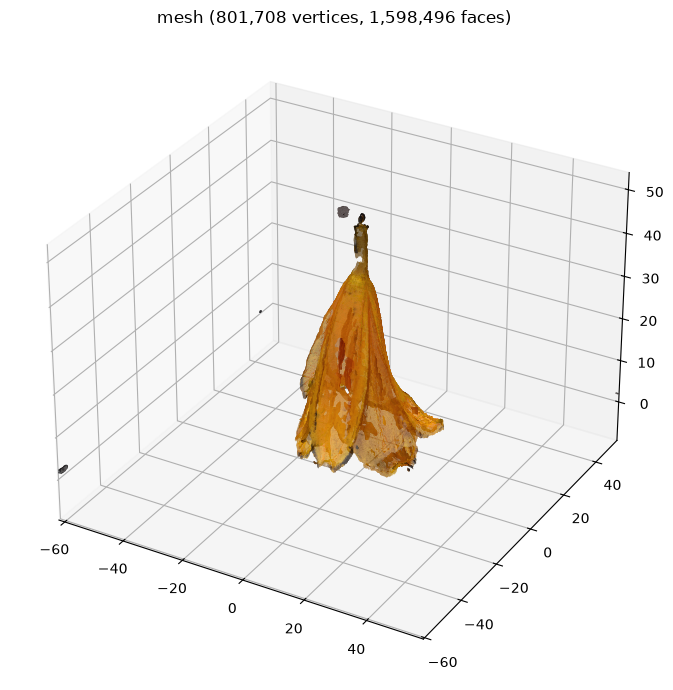

In [8]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
tri_verts = mesh_vertices[mesh_faces]
face_colors = mesh_colors[mesh_faces].mean(axis=1) / 255.0 if mesh_colors is not None else "gray"
pc = Poly3DCollection(tri_verts, facecolor=face_colors, edgecolor="none")
ax.add_collection3d(pc)
ax.set_xlim(mesh_vertices[:, 0].min(), mesh_vertices[:, 0].max())
ax.set_ylim(mesh_vertices[:, 1].min(), mesh_vertices[:, 1].max())
ax.set_zlim(mesh_vertices[:, 2].min(), mesh_vertices[:, 2].max())
ax.set_title(f"mesh ({len(mesh_vertices):,} vertices, {len(mesh_faces):,} faces)")
plt.tight_layout()
plt.show()

## Step 7 - Write the mesh

In [9]:
mesh.write_mesh(OUT_MESH_PLY, tri_mesh)
print(f"wrote {OUT_MESH_PLY}")

wrote /home/gnoceras/ScanningTable/outputs/mesh/mesh.ply


## Summary

In [10]:
print(f"input points:            {len(points):,}")
print(f"after isolation removal: {len(clean_points):,} ({len(points) - len(clean_points):,} removed)")
print(f"Poisson depth:           {POISSON_DEPTH}")
print(f"Poisson time:            {elapsed:.1f}s")
print(f"raw Poisson mesh:        {len(raw_vertices):,} vertices, {len(raw_faces):,} faces")
print(f"after density/debris trim: {len(mesh_vertices):,} vertices, {len(mesh_faces):,} faces "
      f"(trim quantile={POISSON_DENSITY_TRIM_QUANTILE}, min component={MESH_MIN_COMPONENT_TRIANGLES} triangles)")
print(f"wrote:                   {OUT_MESH_PLY}")

input points:            246,997
after isolation removal: 246,997 (0 removed)
Poisson depth:           14
Poisson time:            114.0s
raw Poisson mesh:        826,744 vertices, 1,649,336 faces
after density/debris trim: 801,708 vertices, 1,598,496 faces (trim quantile=0.02, min component=100 triangles)
wrote:                   /home/gnoceras/ScanningTable/outputs/mesh/mesh.ply
